# Cross-validation of Flupyradifurone TKTD model with metamorph data

In [56]:
using DrWatson
@quickactivate "."
#using Pkg; Pkg.instantiate()

In [57]:
using Revise

const SAVETAG_LARVALFIT = "input/Discoglossus_larvae" # directory from which larval/metamorph parameters are loaded
const SAVETAG_JUVENILEFIT = "input/Discoglossus_juveniles" # directory from which juvenile/adult parameters are loaded
const SAVEDIR = "Discoglossus_Flupyradifurone_2025-06-23_numtadpoles" # directory from which TKTD parameters are loaded
const SAVETAG = SAVETAG_TKTD = "Discoglossus_Flupyradifurone" 

using Revise

includet(scriptsdir("ModelFitting_Discoglossus_Flupyradifurone.jl")) 
includet(scriptsdir("CrossValidation_Discoglossus_Flupyradifurone_metamorphs.jl"))

## Generating predictions per PMoA

### $G$

In [7]:
pmoa_idx = 1
pmoa = PMOAS[pmoa_idx]
f = setup_modelfit(pmoa);

┌ Info: Overwriting default values of String31["spc.Z", "spc.dI_max_lrv", "spc.k_M_emb", "spc.eta_AS_emb", "spc.H_j1", "spc.gamma", "spc.k_J_emb", "spc.kappa_emb", "spc.watercontent_larvae", "spc.watercontent_juveniles", "spc.time_since_birth"]
└ @ Main c:\Users\shansul\Documents\AmphiDEBResearch-1\WP02_TKTD\scripts\ModelFitting_Discoglossus_Flupyradifurone.jl:217
┌ Info: Overwriting default values of String15["spc.dI_max_juv", "spc.eta_AS_juv", "spc.H_p", "spc.k_J_juv", "spc.eta_AR"]
└ @ Main c:\Users\shansul\Documents\AmphiDEBResearch-1\WP02_TKTD\scripts\ModelFitting_Discoglossus_Flupyradifurone.jl:226
┌ Info: 
│         Estimating 3 parameters: 
│         ["spc.KD[1,1]", "spc.E[1,1]", "spc.B[1,1]"]
│         
└ @ EcotoxModelFitting C:\Users\shansul\.julia\packages\EcotoxModelFitting\aC0gq\src\modelfit.jl:77
┌ Info: Normalizing data weights
└ @ EcotoxModelFitting C:\Users\shansul\.julia\packages\EcotoxModelFitting\aC0gq\src\modelfit.jl:145
┌ Info: No column `observation_weight` found

In [8]:
using ProgressMeter
p_opt = CSV.read(datadir("sims", SAVEDIR, "$(SAVETAG_TKTD)_$(pmoa)", "posterior_summary.csv"), DataFrame).best_fit
sim_opt_G = @showprogress [f.simulator(p_opt) for _ in 1:1_00];

Progress: 100%|█████████████████████████████████████████| Time: 0:00:20


In [12]:
quant_eval_G = quant_eval_metamorphs(f, sim_opt_G)

Row,endpoint,mre,mre_sd,nrmsd,nrmsd_sd,mape,mape_sd
,String,Float64,Float64,Float64,Float64,Float64,Float64
1,t_exp_G46,0.0429752,0.0537021,3.18393,1.93443,6.53752,3.96872
2,wetmass_G46_mg,0.102666,0.0292743,0.569396,0.150643,10.3288,2.85564


### $\kappa^-$

In [13]:
pmoa_idx = 7
pmoa = PMOAS[pmoa_idx]
f = setup_modelfit(pmoa);

┌ Info: Overwriting default values of String31["spc.Z", "spc.dI_max_lrv", "spc.k_M_emb", "spc.eta_AS_emb", "spc.H_j1", "spc.gamma", "spc.k_J_emb", "spc.kappa_emb", "spc.watercontent_larvae", "spc.watercontent_juveniles", "spc.time_since_birth"]
└ @ Main c:\Users\shansul\Documents\AmphiDEBResearch-1\WP02_TKTD\scripts\ModelFitting_Discoglossus_Flupyradifurone.jl:217
┌ Info: Overwriting default values of String15["spc.dI_max_juv", "spc.eta_AS_juv", "spc.H_p", "spc.k_J_juv", "spc.eta_AR"]
└ @ Main c:\Users\shansul\Documents\AmphiDEBResearch-1\WP02_TKTD\scripts\ModelFitting_Discoglossus_Flupyradifurone.jl:226
┌ Info: 
│         Estimating 3 parameters: 
│         ["spc.KD[1,7]", "spc.E[1,7]", "spc.B[1,7]"]
│         
└ @ EcotoxModelFitting C:\Users\shansul\.julia\packages\EcotoxModelFitting\aC0gq\src\modelfit.jl:77
┌ Info: Normalizing data weights
└ @ EcotoxModelFitting C:\Users\shansul\.julia\packages\EcotoxModelFitting\aC0gq\src\modelfit.jl:145
┌ Info: No column `observation_weight` found

In [15]:
p_opt = CSV.read(datadir("sims", SAVEDIR, "$(SAVETAG_TKTD)_$(pmoa)", "posterior_summary.csv"), DataFrame).best_fit
sim_opt_KAP = @showprogress [f.simulator(p_opt) for _ in 1:1_00];

Progress: 100%|█████████████████████████████████████████| Time: 0:00:16


In [17]:
quant_eval_KAP = quant_eval_metamorphs(f, sim_opt_KAP)

Row,endpoint,mre,mre_sd,nrmsd,nrmsd_sd,mape,mape_sd
,String,Float64,Float64,Float64,Float64,Float64,Float64
1,t_exp_G46,-0.0168926,0.107371,Inf,NaN,9.13356,7.38511
2,wetmass_G46_mg,0.0358513,0.0628965,Inf,NaN,7.47268,4.78503


## Comparing predicted effects on metamorphosis traits

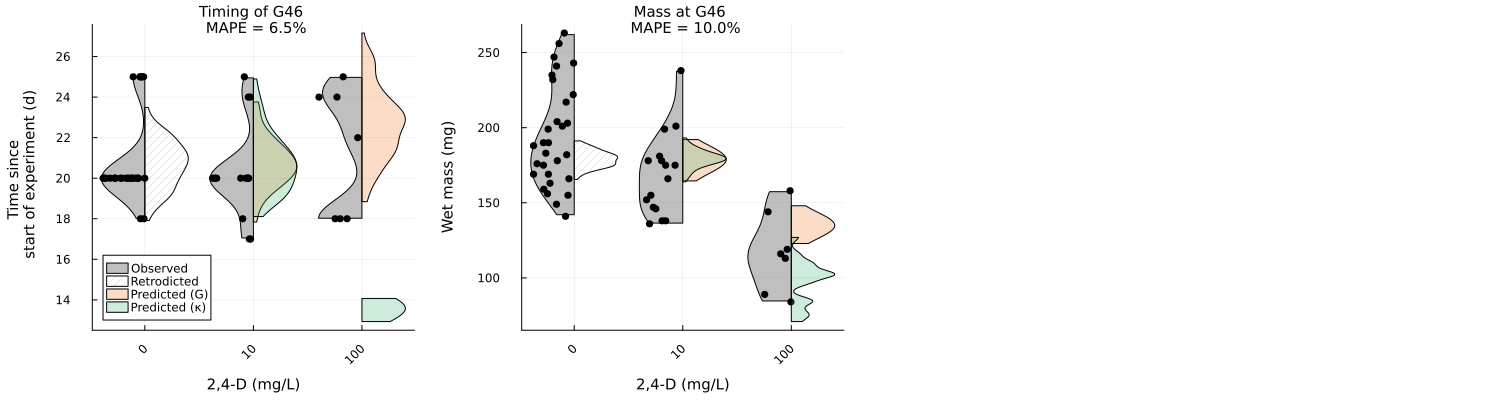

In [55]:
plt = plot_metamorphs(
    leftmargin = 10mm, 
    bottommargin = 10mm,
    )


sim = EcotoxModelFitting.extract_simkey(sim_opt_G, :metamorphs) |> 
x -> @transform(x, :treatment_id = denserank(:C_W_1))
sim_retro = @subset(sim, :treatment_id .== 1)
sim_pred = @subset(sim, :treatment_id .> 1)


@df sim_retro violin!(
    plt, subplot = 1,
    string.(:treatment_id), :t_exp_G46, 
    side = :right,
    fillalpha = .25,
    color = :gray,
    fillstyle = ://,
    label = "Retrodicted",
    )

@df sim_pred violin!(
    plt, subplot = 1,
    string.(:treatment_id), :t_exp_G46, 
    side = :right,
    fillalpha = .25,
    color = :chocolate2,
    label = "Predicted (G)",
    title = "Timing of G46 \n MAPE = $(round(quant_eval_G.mape[1], sigdigits = 2))%"
    )

@df sim_retro violin!(
    plt, subplot = 2,
    string.(:treatment_id), :wetmass_G46_mg, 
    side = :right,
    fillalpha = .25,
    color = :chocolate2,
    fillstyle = ://,
    label = "Predicted (G)",
    )

@df sim_pred violin!(
    plt, subplot = 2,
    string.(:treatment_id), :wetmass_G46_mg, 
    side = :right,
    fillalpha = .25,
    color = :chocolate2,
    label = "Retrodicted",
    title = "Mass at G46 \n MAPE = $(round(quant_eval_G.mape[2], sigdigits = 2))%"
    )


sim = EcotoxModelFitting.extract_simkey(sim_opt_KAP, :metamorphs) |> 
x -> @transform(x, :treatment_id = denserank(:C_W_1))
sim_retro = @subset(sim, :treatment_id .== 1)
sim_pred = @subset(sim, :treatment_id .> 1)


@df sim_pred violin!(
    plt, subplot = 1,
    string.(:treatment_id), :t_exp_G46, 
    side = :right,
    fillalpha = .25,
    color = :mediumseagreen,
    label = "Predicted (κ)",
    title = "Timing of G46 \n MAPE = $(round(quant_eval_G.mape[1], sigdigits = 2))%"
    )

@df sim_pred violin!(
    plt, subplot = 2,
    string.(:treatment_id), :wetmass_G46_mg, 
    side = :right,
    fillalpha = .25,
    color = :mediumseagreen,
    label = "Retrodicted",
    title = "Mass at G46 \n MAPE = $(round(quant_eval_G.mape[2], sigdigits = 2))%"
    )

savefig(
    plot(plt, dpi = 400), 
    plotsdir("CrossValidation_Discoglossus_Flupyradifurone_PMoA_comparison.png")
    #datadir("sims", "$(SAVETAG)_$(PMOAS[pmoa_idx])", "CrossValidation_metamorphs.png")
    )

display(plt)

## Conclusions

The model tends to over-predict the effect on timing of G46 and under-predict the effect on body mass at Gosner 46. <br>
A plausible route to try and improve this might be to incorporate feedbacks in the TK module. <br>
Since metamorphs lose mass, the inclusion of a body size feedback could lead to *concentration by shrinking* 
and a stronger effect on mass at G46. <br>

Another possibility is that damage recovery is slower than implied by the model parameters. This would lead to higher damage and likely also a stronger effect on mass at G46.